In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv('C:/Users/Dell/Desktop/churn-customer-diagnosis/data/processed/telco_churn_cleaned.csv')

model_df = df.drop('customerID', axis=1)
model_df['Churn'] = model_df['Churn'].map({'No': 0, 'Yes': 1})

cat_cols = model_df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    le = LabelEncoder()
    model_df[col] = le.fit_transform(model_df[col])

X = model_df.drop('Churn', axis=1)
y = model_df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

churn_prob = rf.predict_proba(X_test)[:, 1]
print("Predictions generated for", len(churn_prob), "test customers")

Predictions generated for 1409 test customers


### Retention Cost Assumption

For business impact estimation, the average customer retention cost is assumed to be **₹500 per retention call/offer**. This includes customer support efforts, promotional offers, and service discounts provided to reduce churn.

### Build the Business Impact Table

In this step, a business impact table is created using the predictions from the Random Forest model. For each customer, we calculate the churn probability, estimate the Customer Lifetime Value (CLV) using Monthly Charges over an assumed 2-year period, and include a fixed retention cost of ₹500 per customer. Using these values, the expected business value of taking a retention action is calculated to identify whether targeting that customer is financially beneficial.

In [4]:
results = df.loc[X_test.index, ['customerID', 'tenure', 'MonthlyCharges', 'Contract', 'Churn']].copy()
results['Churn_Probability'] = churn_prob

RETENTION_COST = 500         
ASSUMED_REMAINING_MONTHS = 24

results['Estimated_CLV'] = results['MonthlyCharges'] * ASSUMED_REMAINING_MONTHS
results['Expected_Value_If_Saved'] = results['Churn_Probability'] * results['Estimated_CLV']
results['Net_Value_Of_Intervention'] = results['Expected_Value_If_Saved'] - RETENTION_COST

results.sort_values('Net_Value_Of_Intervention', ascending=False).head(10)

,customerID,tenure,MonthlyCharges,Contract,Churn,Churn_Probability,Estimated_CLV,Expected_Value_If_Saved,Net_Value_Of_Intervention
2797,6023-YEBUP,3,100.95,Month-to-month,Yes,0.912646,2422.8,2211.159325,1711.159325
6365,8884-ADFVN,7,101.95,Month-to-month,Yes,0.895202,2446.8,2190.379083,1690.379083
2631,6861-XWTWQ,7,99.25,Month-to-month,Yes,0.898043,2382.0,2139.137502,1639.137502
3956,4587-VVTOX,6,105.30,Month-to-month,Yes,0.845069,2527.2,2135.657301,1635.657301
2448,9221-OTIVJ,14,104.85,Month-to-month,Yes,0.843328,2516.4,2122.149471,1622.149471
3727,9057-SIHCH,3,96.60,Month-to-month,Yes,0.912788,2318.4,2116.208076,1616.208076
3380,5178-LMXOP,1,95.10,Month-to-month,Yes,0.925573,2282.4,2112.527140,1612.527140
2294,2027-FECZV,12,106.70,Month-to-month,Yes,0.817682,2560.8,2093.920430,1593.920430
6894,1400-MMYXY,3,105.90,Month-to-month,Yes,0.821677,2541.6,2088.373203,1588.373203
4039,8161-QYMTT,7,94.10,Month-to-month,No,0.924426,2258.4,2087.722907,1587.722907


### Segment Customers into an Action Matrix

In this step, customers are grouped into four categories based on churn risk and customer value (CLV) to identify the most important customers for retention actions.

In [5]:
risk_threshold = 0.5   # probability above this = "high risk"
value_threshold = results['Estimated_CLV'].median()  # above median = "high value"

def segment(row):
    high_risk = row['Churn_Probability'] >= risk_threshold
    high_value = row['Estimated_CLV'] >= value_threshold
    if high_risk and high_value:
        return 'Call Immediately (High Risk, High Value)'
    elif high_risk and not high_value:
        return 'Low-Cost Offer (High Risk, Low Value)'
    elif not high_risk and high_value:
        return 'Monitor (Low Risk, High Value)'
    else:
        return 'No Action (Low Risk, Low Value)'

results['Segment'] = results.apply(segment, axis=1)
segment_summary = results['Segment'].value_counts()
print(segment_summary)

segment_summary.to_csv('C:/Users/Dell/Desktop/churn-customer-diagnosis/reports/segment_summary.csv')

Segment
No Action (Low Risk, Low Value)             574
Monitor (Low Risk, High Value)              359
Call Immediately (High Risk, High Value)    346
Low-Cost Offer (High Risk, Low Value)       130
Name: count, dtype: int64


### Visualize the Action Matrix

In this step, a scatter plot is created to visualize customer churn risk and customer value (CLV), helping identify which customers should be prioritized for retention actions.

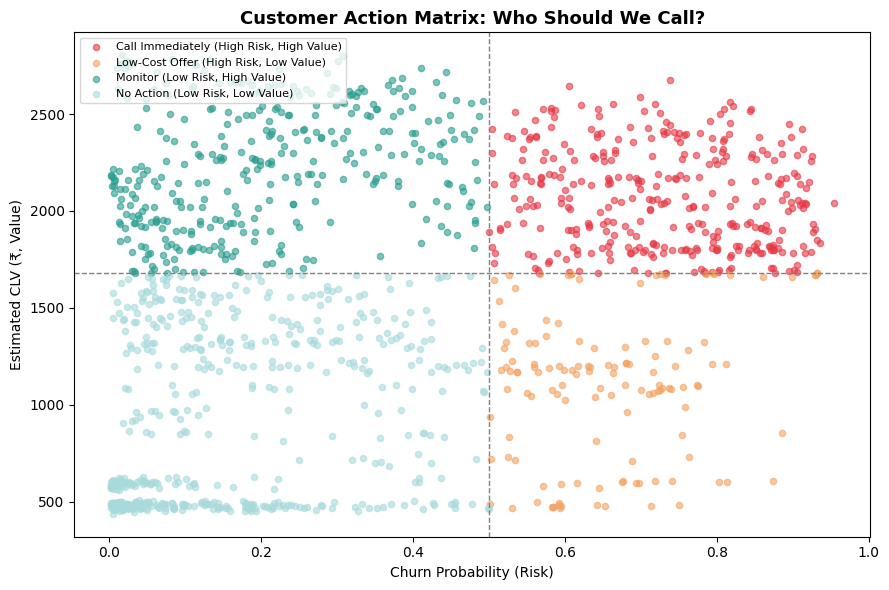

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 6))
colors = {
    'Call Immediately (High Risk, High Value)': '#E63946',
    'Low-Cost Offer (High Risk, Low Value)': '#F4A261',
    'Monitor (Low Risk, High Value)': '#2A9D8F',
    'No Action (Low Risk, Low Value)': '#A8DADC'
}

for seg, color in colors.items():
    subset = results[results['Segment'] == seg]
    ax.scatter(subset['Churn_Probability'], subset['Estimated_CLV'],
               c=color, label=seg, alpha=0.6, s=20)

ax.axvline(risk_threshold, color='gray', linestyle='--', linewidth=1)
ax.axhline(value_threshold, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Churn Probability (Risk)')
ax.set_ylabel('Estimated CLV (₹, Value)')
ax.set_title('Customer Action Matrix: Who Should We Call?', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('C:/Users/Dell/Desktop/churn-customer-diagnosis/reports/07_action_matrix.png', dpi=150)
plt.show()

### Total Potential Value at Stake
In this step, the total business value that could be saved by retaining high-risk customers in the “Call Immediately” segment is calculated.

In [9]:
call_segment = results[results['Segment'] == 'Call Immediately (High Risk, High Value)']

total_at_risk_value = call_segment['Estimated_CLV'].sum()
total_intervention_cost = len(call_segment) * RETENTION_COST
expected_value_saved = call_segment['Net_Value_Of_Intervention'].sum()

print(f"Customers in 'Call Immediately' segment: {len(call_segment)}")
print(f"Total CLV at risk in this segment: ₹{total_at_risk_value:,.0f}")
print(f"Total cost to intervene on all of them: ₹{total_intervention_cost:,.0f}")
print(f"Total expected net value if interventions work: ₹{expected_value_saved:,.0f}")

Customers in 'Call Immediately' segment: 346
Total CLV at risk in this segment: ₹714,746
Total cost to intervene on all of them: ₹173,000
Total expected net value if interventions work: ₹348,128
